In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from tqdm import tqdm




What transformations might be useful when working with images?
Adding padding to resize the images to $32\times32$ pixels and converting them to PyTorch tensors.

1. Load and Visualize the Dataset


In [19]:
# Preprocessing
transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor()
])
# Pad 28x28 images to 32x32
# Convert images to tensors

batch_size = 64

# load data
train_dataset = datasets.FashionMNIST(root="./data", train=True, 
                                      transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = datasets.FashionMNIST(root="./data", train=False, 
                                    transform=transform, download=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

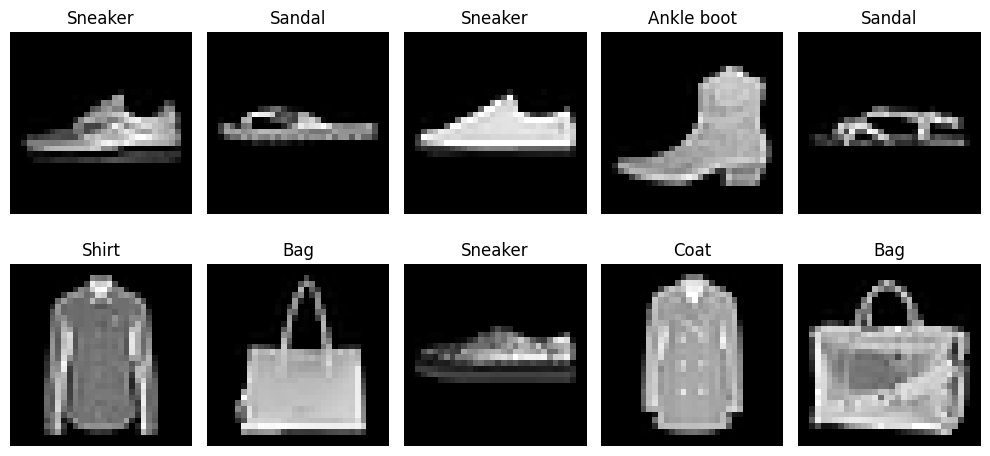

In [20]:
class_labels = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

def plot_sample_images(loader):
    data_iter = iter(loader) 
    
    
    images, labels = next(data_iter)
    
    images = images.numpy()
    
    plt.figure(figsize=(10, 5))
    
    for i in range(10):
        plt.subplot(2, 5, i+1)
        
        plt.imshow(images[i].squeeze(), cmap="gray")
        
        plt.title(class_labels[labels[i].item()])
        
        plt.axis("off") 
        
    plt.tight_layout()
    plt.show()

plot_sample_images(train_loader)

2. Build the Autoencoder

How does reducing the dimensionality help the model?


It forces the model to compress the data, meaning it learns only the most important visual features and ignores useless noise.


What happens if the latent space is too small or too large? 

If it is too small, the model loses too much information, resulting in blurry images. If it is too large, the model simply memorizes the data without learning the underlying patterns (overfitting).

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, input_shape=(1, 32, 32), latent_dim=2):
        """
        Initialize the Autoencoder model.
        input_shape: The shape of the input images (1, 32, 32) for grayscale images.
        latent_dim: The number of neurons in the latent space.
        """
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(), # activation function
            
            # Second convolutional layer
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(), # activation function
            
            # Third convolutional layer
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU() # activation function
        )

        # Dynamically calculate the flattened size after encoding
        flattened_size, decode_shape = self.calculate_flattened_size(self.encoder, input_shape)

        # Latent space (fully connected layer)
        self.fc = nn.Sequential(
            nn.Flatten(start_dim=1), # Flatten the encoded features
            nn.Linear(flattened_size, latent_dim) # Replace with the latent dimension
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, flattened_size), # Map latent space back to the feature map
            nn.Unflatten(decode_shape[0], decode_shape[1:]), # Reshape to match the encoded feature map
            
            # Transposed Convolution layers (Decoder)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(), # activation function
            
            # Next deconvolution layer
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(), # activation function
            
            # Final deconvolution layer: Convert back to single-channel grayscale image
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Output values should be between 0 and 1
        )

    def calculate_flattened_size(self, model, input_shape):
        """Helper function to determine the flattened size after the encoder."""
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape) # Create a batch of one image
            output = model(dummy_input)
        return output.numel(), output.shape # Return total number of elements and shape

    def forward(self, x):
        """Forward pass through the Autoencoder."""
        x = self.encoder(x) # Pass through the encoder
        latent = self.fc(x) # Project into latent space
        x = self.decoder(latent) # Decode the latent representation
        return x, latent

In [22]:
# Test dimension consistency
x_sample = torch.randn(1, 1, 32, 32) 
model_test = Autoencoder() 

# On passe notre fausse image dans le modèle
image_test, latent_space = model_test(x_sample) 

# On vérifie que les dimensions correspondent
assert image_test.shape == x_sample.shape, "Output dimensions do not match input dimensions!" [cite: 174-175]
print("Test réussi ! Les dimensions de sortie correspondent aux dimensions d'entrée.")

Test réussi ! Les dimensions de sortie correspondent aux dimensions d'entrée.


3. Train the Autoencoder


Start Training...


Epoch 1/10:   0%|          | 0/938 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 157/157 [00:01<00:00, 94.27it/s]


Epoch [1/10], Train Loss: 0.084140 %, Val Loss: 0.056880 %,  Val Loss cross_entropy: 0.470653 %


Evaluating: 100%|██████████| 157/157 [00:01<00:00, 90.44it/s]


...

Epoch [8/10], Train Loss: 0.039635 %, Val Loss: 0.039354 %,  Val Loss cross_entropy: 0.417042 %


Evaluating: 100%|██████████| 157/157 [00:01<00:00, 89.52it/s]


Epoch [9/10], Train Loss: 0.039077 %, Val Loss: 0.039093 %,  Val Loss cross_entropy: 0.415336 %


Evaluating: 100%|██████████| 157/157 [00:01<00:00, 90.75it/s]

Epoch [10/10], Train Loss: 0.038588 %, Val Loss: 0.038443 %,  Val Loss cross_entropy: 0.413170 %


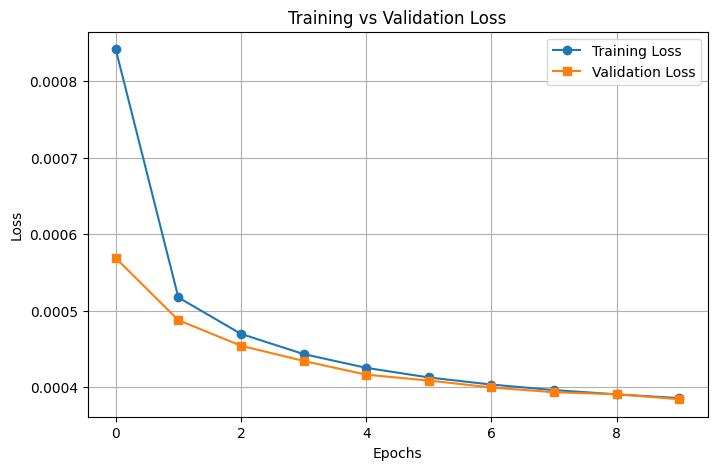

In [23]:
from tqdm import tqdm
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, train_loader, val_loader, epochs):
    """
    Train the Autoencoder model.
    
    - model: The Autoencoder instance.
    - train_loader: DataLoader for training data.
    - val_loader: DataLoader for validation data.
    - epochs: Number of training iterations.
    """
    model.to(device) # Move model to device
    
    # Choix de l'optimiseur (Adam) et du taux d'apprentissage (0.0001)
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    loss_fn = nn.MSELoss() # Define the loss function
    print("Start Training...") 
    
    # Lists to store loss values for plotting
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train() # Set model to training mode 
        total_loss = 0
        tqdm_loader = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for x, _ in tqdm_loader:
            x = x.to(device) # Move batch to device
            
            # Forward pass: get reconstructed output
            recon_x, _ = model(x)
            
            # Compute reconstruction loss: MSE loss between `recon_x` and `x`
            loss = loss_fn(recon_x, x)
            
            # Backpropagation
            optimizer.zero_grad()
            loss.backward() # Compute gradients
            optimizer.step() # Update weights
            
            total_loss += loss.item() # Accumulate batch loss
            
            # Update tqdm progress bar with loss
            tqdm_loader.set_postfix(loss=loss.item())

        # Calculate average loss over the epoch
        avg_train_loss = total_loss / len(train_loader.dataset)
        
        # for val get Mean Squared Error and cross_entropy
        avg_val_loss, ce_losss = evaluate_model(model, val_loader)
        
        # Store losses for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {100*avg_train_loss:.6f} %, Val Loss: {100*avg_val_loss:.6f} %,  Val Loss cross_entropy: {100*ce_losss:.6f} %")
        
    # Plot training and validation loss
    plot_training_loss(train_losses, val_losses)

# Evaluation function
def evaluate_model(model, loader):
    """
    Evaluate the model on validation data.
    
    - model: Trained Autoencoder model.
    - loader: DataLoader for validation data.
    
    Returns:
    - avg_loss: The average loss across all validation samples.
    """
    model.eval() # Set model to evaluation mode
    total_loss = 0
    loss_fn = nn.MSELoss() # Use the same loss function as training
    ce_losss = 0
    
    with torch.no_grad():  # No need to compute gradients
        for x, _ in tqdm(loader, desc="Evaluating"):
            x = x.to(device)
            recon_x, _ = model(x) # Get reconstruction
            
            loss = loss_fn(recon_x, x) # Compute loss between recon_x and x
            ce_loss = F.binary_cross_entropy(recon_x, x)
            
            total_loss += loss.item()
            ce_losss += ce_loss

    avg_loss = total_loss / len(loader.dataset)
    ce_losss /= len(loader.dataset)
    return avg_loss, ce_losss

def plot_training_loss(train_losses, val_losses):
    """
    Plot the training and validation loss across epochs.

    - train_losses: List of training losses per epoch.
    - val_losses: List of validation losses per epoch.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Training Loss", marker="o")
    plt.plot(val_losses, label="Validation Loss", marker="s")
    
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

# Instantiate and train the model
autoencoder = Autoencoder() 
train_model(autoencoder, train_loader, val_loader, epochs=10)

4. Reconstruct Images Using the Autoencode

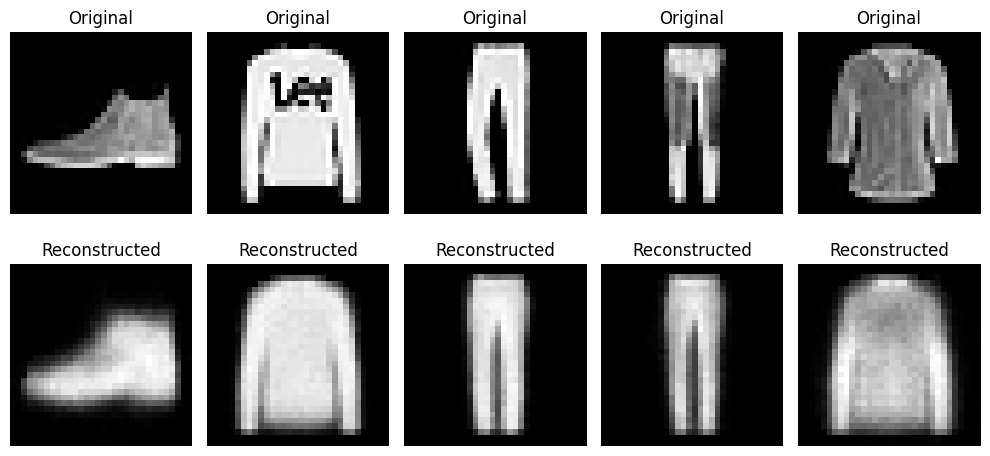

In [24]:
# Function to plot reconstructions
def plot_reconstructions(model, loader, ex=True):
    model.eval() # Set the model to evaluation mode
    model = model.to("cpu") # Move model to CPU for visualization
    
    with torch.no_grad():
        if ex:
            for x, _ in loader: # Extract a batch from DataLoader
                recon_x, _ = model(x)
                break
        else:
            x = loader # Directly use provided latent vectors
            recon_x = model.decoder(x) # Decode latent space samples
            
    # Convert tensors to NumPy for plotting
    x = x.cpu().numpy()
    recon_x = recon_x.cpu().numpy()
    
    plt.figure(figsize=(10, 5))
    for i in range(5):
        # Plot Original images (only if batch came from real data)
        if ex:
            plt.subplot(2, 5, i + 1)
            plt.imshow(x[i].squeeze(), cmap="gray")
            plt.title("Original")
            plt.axis("off")
            
        # Plot Reconstructed images
        plt.subplot(2, 5, i + 6)
        plt.imshow(recon_x[i].squeeze(), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Appel de la fonction pour afficher les résultats
plot_reconstructions(autoencoder, val_loader)

How could you improve the model to get sharper images?

To improve the model to have sharper images we can : 
 - Increase latent space size 
 - Improve the architecture : add convolution layer
 - Change the Loss function to improve the results

5. Visualize the Latent Space


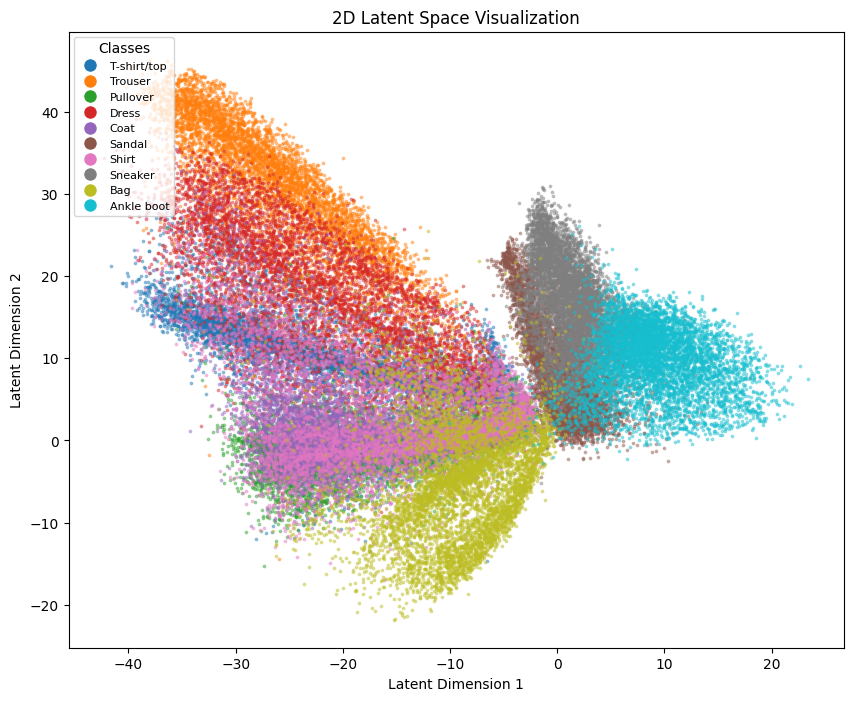

In [25]:
import numpy as np
from matplotlib.lines import Line2D

# Initialize lists to store embeddings and corresponding labels
embeddings = []
labels = []

# Move the Autoencoder to the appropriate device
autoencoder = autoencoder.to(device)

# Disable gradient computation for efficiency
with torch.no_grad():
    for x, y in train_loader: # Iterate over training batches
        x = x.to(device) # Move batch to device
        
        # Pass the images through the encoder to get latent space representations
        # La fonction forward renvoie (image_reconstruite, espace_latent)
        _, latent = autoencoder(x) 
        
        # Convert to NumPy and store results
        embeddings.append(latent.cpu().numpy())
        labels.append(y.numpy())

# Combine embeddings and labels into single arrays
embeddings = np.concatenate(embeddings, axis=0) # Use NumPy to concatenate the embeddings
labels = np.concatenate(labels, axis=0) # Similarly, concatenate the labels

# Identify unique class labels
unique_labels = np.unique(labels)
autoencoder = autoencoder.to("cpu")

# Plot the 2D embeddings
# Generate more distinguishable colors for each class using a categorical colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

# Scatter plot
plt.figure(figsize=(10, 8))
legend_handles = []

for i, label in enumerate(unique_labels):
    indices = np.where(labels == label)[0]
    
    plt.scatter(
        embeddings[indices, 0], embeddings[indices, 1],
        c=[colors[i]], alpha=0.4, s=3, label=class_labels[label]
    )
    
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w',
               label=f'{class_labels[label]}',
               markersize=10, markerfacecolor=colors[i])
    )

plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('2D Latent Space Visualization')
plt.legend(handles=legend_handles, title='Classes', loc='upper left', fontsize=8)
plt.show()

Would images of similar clothing types cluster together and are they well represented ?

Yes as we see, differents type of shoes are grouping together, pant are isolated, the tops are mixed also. 

Generated Latent Samples: 
 tensor([[-23.8924, -11.5798],
        [ -8.7089,  -0.2068],
        [-25.9397,  33.2934],
        [-20.1840,  34.1696],
        [-21.2826, -13.5767]])


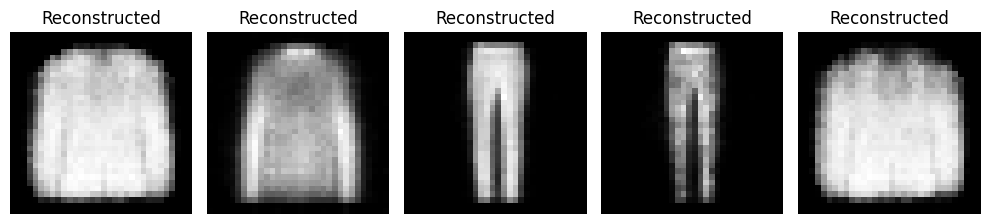

In [26]:
# Generate latent space samples for visualization
mins, maxs = np.min(embeddings, axis=0), np.max(embeddings, axis=0)

# On tire 5 points aléatoires avec 2 coordonnées (x, y)
sample = torch.tensor(np.random.uniform(mins, maxs, size=(5, 2)), dtype=torch.float32)

# Print the sampled latent vectors
print("Generated Latent Samples: \n", sample)

# Plot reconstructions from sampled latent space (ex=False car on donne directement les coordonnées)
plot_reconstructions(autoencoder, sample, ex=False)

Are there any objects not well reconstructed ?

Yes, objects with fine details (like complex patterns, logos on shirts, or specific bag straps) are poorly reconstructed because the 2D latent space is too small to store those fine details.

In [27]:
# Save the model
torch.save(autoencoder.state_dict(), "VAmodel_state_dict.pth")